In [1]:
# Import Library

import yfinance as yf
import urllib.parse
import matplotlib.pyplot as plt

import pandas as pd
import time
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import pandas as pd
import numpy as np
from textblob import TextBlob
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [2]:
# Load News from Google
df_news_google = pd.read_csv("news_sentiment_google.csv")
df_news_google.head()

,keyword,headline,link,date
0,interest rates,TIA-i May 2025 Campaign | Returns up to 3.80% ...,https://news.google.com/rss/articles/CBMijAFBV...,2024-08-29 11:13:49
1,interest rates,BSN MYGOLD ACCOUNT-i - bsn.com.my,https://news.google.com/rss/articles/CBMiWkFVX...,2023-08-28 00:23:19
2,interest rates,Personal Loan | Flexible Financing Plans - UOB...,https://news.google.com/rss/articles/CBMiaEFVX...,2019-08-03 23:36:08
3,interest rates,EzyCash | Instant Cash From Your Credit Card |...,https://news.google.com/rss/articles/CBMinAFBV...,2020-06-04 06:21:22
4,interest rates,Premier Banking | Apply Premier Account Online...,https://news.google.com/rss/articles/CBMioAFBV...,2019-05-12 13:18:59


In [3]:
# Load News from NST
#df_news_nst = pd.read_csv("news_headlines_nst.csv")
#df_news_nst.head()

In [4]:
# Load the CSV with multi-level headers
df_index = pd.read_csv('KLCI_Historical_Data.csv', header=[0, 1], skiprows = 1)

# Flatten multi-level headers
df_index.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_index.columns.values]

# Rename the first column to 'Date'
df_index = df_index.rename(columns={df_index.columns[0]: 'date'})

# Convert 'date' column to datetime format
df_index['date'] = pd.to_datetime(df_index['date'])

# Preview
print(df_index.head())


        date  ^KLSE_Unnamed: 1_level_1  ^KLSE_Unnamed: 2_level_1  \
0 2019-01-02               1668.109985               1694.099976   
1 2019-01-03               1675.829956               1680.780029   
2 2019-01-04               1669.780029               1676.550049   
3 2019-01-07               1679.170044               1687.130005   
4 2019-01-08               1672.760010               1686.369995   

   ^KLSE_Unnamed: 3_level_1  ^KLSE_Unnamed: 4_level_1  \
0               1666.069946               1693.510010   
1               1666.219971               1675.160034   
2               1668.150024               1672.579956   
3               1673.030029               1674.920044   
4               1670.670044               1685.719971   

   ^KLSE_Unnamed: 5_level_1  
0                  47769800  
1                  69484500  
2                  64869000  
3                 144668500  
4                 176071900  


In [5]:
df_news_google.shape, df_index.shape

((525, 4), (1470, 6))

In [6]:
df_news = df_news_google.drop(columns=['link'])

In [7]:
# Rename columns to be consistent
df_news.rename(columns={'date': 'Date'}, inplace=True)
df_index.rename(columns={'date': 'Date'}, inplace=True)  # if needed

# Ensure both 'Date' columns are in datetime format and named the same
df_news['Date'] = pd.to_datetime(df_news['Date']).dt.date
df_index['Date'] = pd.to_datetime(df_index['Date']).dt.date


In [8]:
print(df_news.columns)
print(df_index.columns)

Index(['keyword', 'headline', 'Date'], dtype='object')
Index(['Date', '^KLSE_Unnamed: 1_level_1', '^KLSE_Unnamed: 2_level_1',
       '^KLSE_Unnamed: 3_level_1', '^KLSE_Unnamed: 4_level_1',
       '^KLSE_Unnamed: 5_level_1'],
      dtype='object')


In [9]:
# Rename the columns in df_index
df_index = df_index.rename(columns={
    '^KLSE_Unnamed: 1_level_1': 'Close',
    '^KLSE_Unnamed: 2_level_1': 'High',
    '^KLSE_Unnamed: 3_level_1': 'Low',
    '^KLSE_Unnamed: 4_level_1': 'Open',
    '^KLSE_Unnamed: 5_level_1': 'Volume'
})


DATA CLEANING

In [10]:
# Function to check if a headline is clean (only contains standard printable characters)
def is_clean_text(text):
    return bool(re.match(r'^[A-Za-z0-9\s.,;:?!\'\"()\-&%$@]+$', text))

# Apply the filter
df_news_cleaned = df_news[df_news['headline'].apply(is_clean_text)]

# Optionally, reset index
df_news_cleaned = df_news_cleaned.reset_index(drop=True)

# Preview result
print(df_news_cleaned.head())


          keyword                                   headline        Date
0  interest rates          BSN MYGOLD ACCOUNT-i - bsn.com.my  2023-08-28
1  interest rates  Monetary Stability - Bank Negara Malaysia  2020-12-18
2  interest rates    Everyday Global Account - HSBC Malaysia  2019-06-10
3  interest rates   Loans for Small Business - Alliance Bank  2023-11-04
4  interest rates        UOB Balance Transfer - UOB Malaysia  2019-08-05


In [11]:
# Ensure 'Date' columns are datetime objects and have no time component
df_index['Date'] = pd.to_datetime(df_index['Date']).dt.date
df_news_cleaned['Date'] = pd.to_datetime(df_news_cleaned['Date']).dt.date

# Merge: keep all index dates, match news where available
df_combined = pd.merge(df_index, df_news_cleaned, on='Date', how='left')

df_combined


,Date,Close,High,Low,Open,Volume,keyword,headline
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN,NaN
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN,NaN
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN,NaN
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN,NaN
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN,NaN
...,...,...,...,...,...,...,...,...
1577,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,NaN,NaN
1578,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,tightening,Skin Tightening and Lifting Treatment - MH Clinic
1579,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,political instability,"Military Connections, Investment Efficiency an..."
1580,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,NaN,NaN


In [12]:
# Group headlines by Date (join multiple headlines into one string)
aggregated_news = df_news_cleaned.groupby('Date')['headline'].apply(' | '.join).reset_index()

# Left join to retain all dates from the index
df_combined = df_index.merge(aggregated_news, on='Date', how='left')


In [13]:
# Replace NaN with empty string if preferred
df_combined['headline'] = df_combined['headline'].fillna('')

# Export
df_combined.to_csv('klci_with_headlines.csv', index=False)
df_combined


,Date,Close,High,Low,Open,Volume,headline
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,
...,...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,Skin Tightening and Lifting Treatment - MH Clinic
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Military Connections, Investment Efficiency an..."
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,


SENTIMENT ANALYSIS USING TEXTBLOB AND VADER

In [14]:
#Sentiment Analysis using TextBlob
# get subjectivity:
def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

# get polarity:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

In [15]:
#Get Subjectivity and polarity 
df_combined['Polarity'] = df_combined['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_combined['Subjectivity'] = df_combined['headline'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Preview results
print(df_combined[['headline', 'Polarity', 'Subjectivity', ]].head())

# Optionally save to CSV
df_combined.to_csv('news_with_text_sentiment.csv', index=False)

  headline  Polarity  Subjectivity
0                0.0           0.0
1                0.0           0.0
2                0.0           0.0
3                0.0           0.0
4                0.0           0.0


In [16]:
df_text = pd.read_csv('news_with_text_sentiment.csv')
df_text

,Date,Close,High,Low,Open,Volume,headline,Polarity,Subjectivity
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN,0.00,0.0
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN,0.00,0.0
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN,0.00,0.0
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN,0.00,0.0
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN,0.00,0.0
...,...,...,...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,NaN,0.00,0.0
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,Skin Tightening and Lifting Treatment - MH Clinic,0.00,0.0
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Military Connections, Investment Efficiency an...",-0.05,0.1
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,NaN,0.00,0.0


In [17]:
# Define sentiment category function
def get_sentiment(polarity):
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment category
df_text['Sentiment'] = df_text['Polarity'].apply(get_sentiment)

# Preview
print(df_text[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'headline', 'Polarity', 'Subjectivity', 'Sentiment']].head())


         Date        Close         High          Low         Open     Volume  \
0  2019-01-02  1668.109985  1694.099976  1666.069946  1693.510010   47769800   
1  2019-01-03  1675.829956  1680.780029  1666.219971  1675.160034   69484500   
2  2019-01-04  1669.780029  1676.550049  1668.150024  1672.579956   64869000   
3  2019-01-07  1679.170044  1687.130005  1673.030029  1674.920044  144668500   
4  2019-01-08  1672.760010  1686.369995  1670.670044  1685.719971  176071900   

  headline  Polarity  Subjectivity Sentiment  
0      NaN       0.0           0.0   Neutral  
1      NaN       0.0           0.0   Neutral  
2      NaN       0.0           0.0   Neutral  
3      NaN       0.0           0.0   Neutral  
4      NaN       0.0           0.0   Neutral  


In [18]:
#df_sentiment = pd.read_csv('klci_with_headlines.csv')
#df_sentiment

In [19]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

In [20]:
# Ensure all values in 'headline' column are strings and fill NaNs
df_text['headline'] = df_text['headline'].fillna("").astype(str)

# Apply sentiment scoring
df_text['VADER_Score'] = df_text['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Categorize sentiment
def categorize_vader(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_text['VADER_Sentiment'] = df_text['VADER_Score'].apply(categorize_vader)

# Preview result
df_text.head()


,Date,Close,High,Low,Open,Volume,headline,Polarity,Subjectivity,Sentiment,VADER_Score,VADER_Sentiment
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,,0.0,0.0,Neutral,0.0,Neutral
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,,0.0,0.0,Neutral,0.0,Neutral
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,,0.0,0.0,Neutral,0.0,Neutral
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,,0.0,0.0,Neutral,0.0,Neutral
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,,0.0,0.0,Neutral,0.0,Neutral


In [21]:
df_merged= df_text[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'headline','Polarity', 'Subjectivity','Sentiment', 'VADER_Score', 'VADER_Sentiment']]

# Export to CSV
df_merged.to_csv('merged_KLCI_sentiments.csv', index=False)
df_merged

,Date,Close,High,Low,Open,Volume,headline,Polarity,Subjectivity,Sentiment,VADER_Score,VADER_Sentiment
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,,0.00,0.0,Neutral,0.0000,Neutral
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,,0.00,0.0,Neutral,0.0000,Neutral
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,,0.00,0.0,Neutral,0.0000,Neutral
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,,0.00,0.0,Neutral,0.0000,Neutral
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,,0.00,0.0,Neutral,0.0000,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,,0.00,0.0,Neutral,0.0000,Neutral
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,Skin Tightening and Lifting Treatment - MH Clinic,0.00,0.0,Neutral,0.0000,Neutral
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Military Connections, Investment Efficiency an...",-0.05,0.1,Neutral,0.0258,Neutral
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,,0.00,0.0,Neutral,0.0000,Neutral


DATA VISUALIZATION

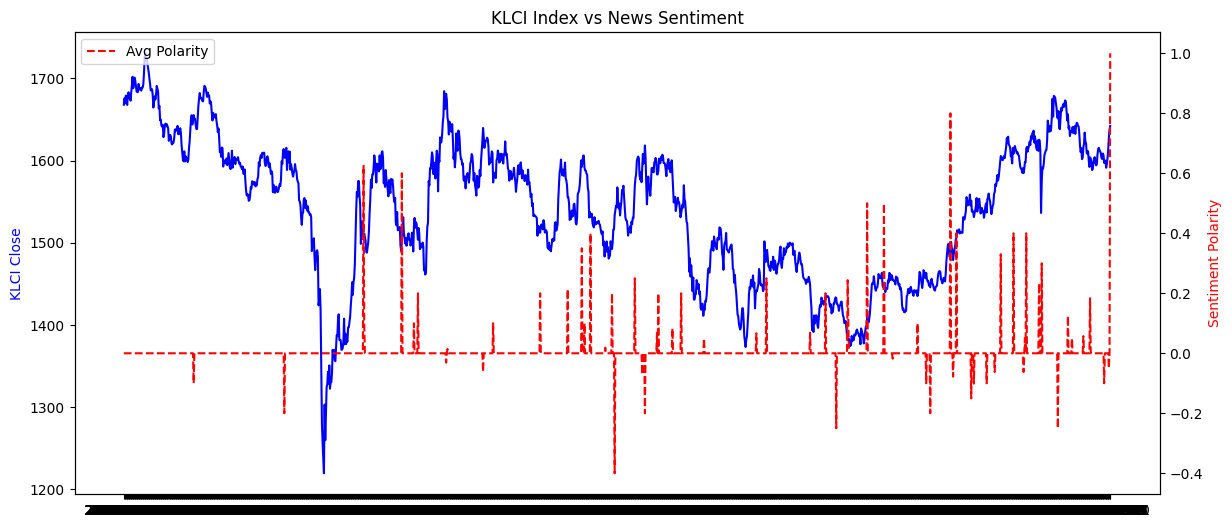

In [22]:
# Group by Date and get average polarity per day
daily_sentiment = df_merged.groupby('Date')['Polarity'].mean()

# Plot
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df_merged['Date'], df_merged['Close'], color='blue', label='KLCI Close')
ax1.set_ylabel('KLCI Close', color='blue')

ax2 = ax1.twinx()
ax2.plot(df_merged['Date'], df_merged['Polarity'], color='red', linestyle='--', label='Avg Polarity')
ax2.set_ylabel('Sentiment Polarity', color='red')

plt.title('KLCI Index vs News Sentiment')
plt.legend(loc='upper left')
plt.show()

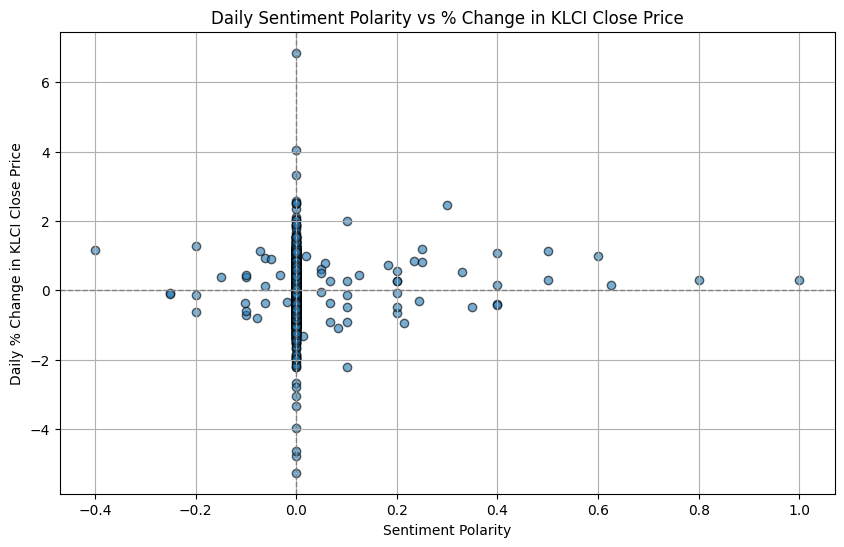

In [23]:
#Scatter Plot: Sentiment vs Index Movement - how daily sentiment scores correlate with the change in KLCI close price
# Calculate daily % change
# Calculate daily % change in Close price
df_merged['Close_Change'] = df_merged['Close'].pct_change() * 100  # in percentage

# Calculate polarity sentiment score using TextBlob
df_merged['Polarity'] = df_merged['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Drop NaN rows resulting from pct_change at first row
df_merged.dropna(subset=['Close_Change', 'Polarity'], inplace=True)

# Scatter Plot: Polarity vs Close Change
plt.figure(figsize=(10, 6))
plt.scatter(df_merged['Polarity'], df_merged['Close_Change'], alpha=0.6, edgecolors='k')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Daily Sentiment Polarity vs % Change in KLCI Close Price')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Daily % Change in KLCI Close Price')
plt.grid(True)
plt.show()

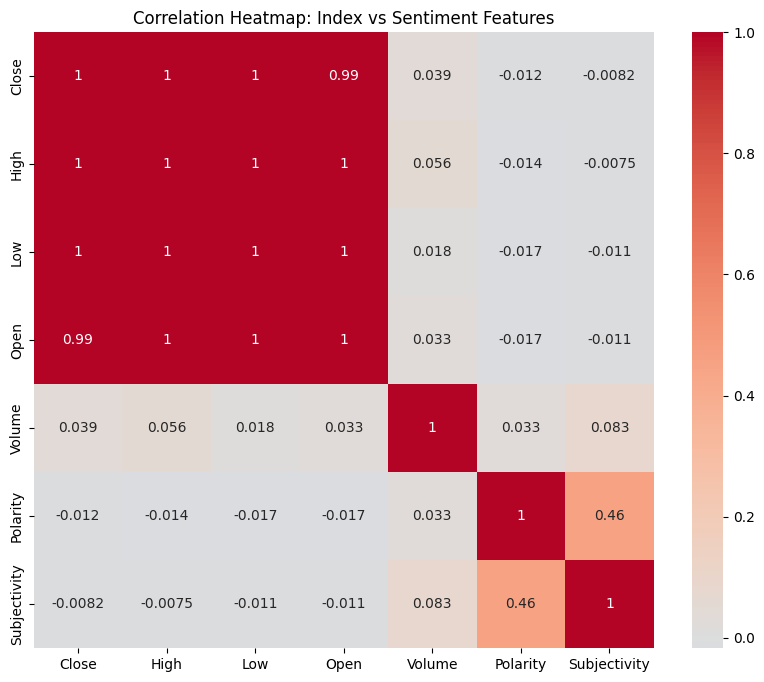

In [24]:
#Heatmap of Correlations
#Purpose: Quickly view correlations between numerical variables like Polarity, Subjectivity, VADER Score, and Index features.

import seaborn as sns

# Select relevant columns
correlation_data = df_merged[['Close', 'High', 'Low', 'Open', 'Volume', 'Polarity', 'Subjectivity']]

# Compute correlation matrix
corr_matrix = correlation_data.corr()

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Index vs Sentiment Features')
plt.show()


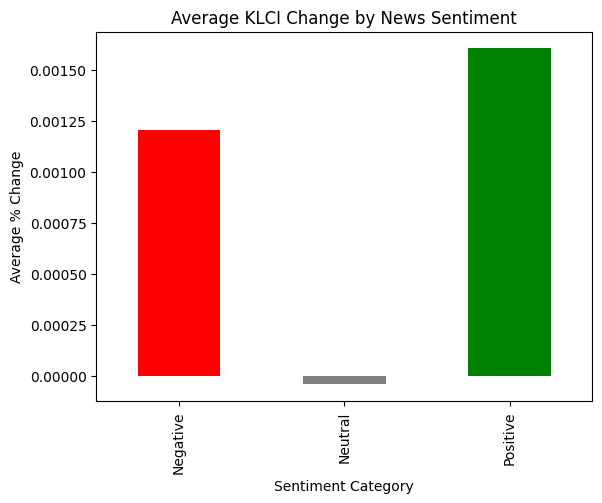

In [25]:
#Bar Plot: Average Index Change by Sentiment Category
#Purpose: See how index moves depending on headline sentiment (Positive, Neutral, Negative).
# Group by sentiment category
df_merged['Close_Change'] = df_merged['Date'].map(df_merged.set_index('Date')['Close'].pct_change())
avg_change_by_sentiment = df_merged.groupby('Sentiment')['Close_Change'].mean()

# Plot
avg_change_by_sentiment.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Average KLCI Change by News Sentiment')
plt.ylabel('Average % Change')
plt.xlabel('Sentiment Category')
plt.show()


SentimentIntensityAnalyzer:

In [26]:
# Initialize VADER analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring
df_merged['VADER_Score'] = df_merged['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Categorize sentiment based on VADER compound score
def categorize_vader(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_merged['VADER_Sentiment'] = df_merged['VADER_Score'].apply(categorize_vader)

# Preview
print(df_merged[['headline', 'VADER_Score', 'VADER_Sentiment']].head())

# Export to CSV
df_merged.to_csv('news_with_vader_sentiment.csv', index=False)


  headline  VADER_Score VADER_Sentiment
1                   0.0         Neutral
2                   0.0         Neutral
3                   0.0         Neutral
4                   0.0         Neutral
5                   0.0         Neutral


LINEAR REGRESSION MODEL

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [28]:
# Linear Regression for VADER-based prediction
X_vader = df_merged[['VADER_Score']]
y_vader = df_merged['Close']

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vader, y_vader, test_size=0.2, random_state=42)
model_vader = LinearRegression()
model_vader.fit(X_train_v, y_train_v)
y_pred_vader = model_vader.predict(X_test_v)

print("VADER - RMSE:", root_mean_squared_error(y_test_v, y_pred_vader))
print("VADER - R²:", r2_score(y_test_v, y_pred_vader))


VADER - RMSE: 86.9292403624946
VADER - R²: -0.002834349193148844


In [29]:
# Linear Regression for TextBlob-based prediction
X_textblob = df_merged[['Polarity']]
y_textblob = df_merged['Close']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_textblob, y_textblob, test_size=0.2, random_state=42)
model_textblob = LinearRegression()
model_textblob.fit(X_train_t, y_train_t)
y_pred_textblob = model_textblob.predict(X_test_t)


print("TextBlob - RMSE:", root_mean_squared_error(y_test_t, y_pred_textblob))
print("TextBlob - R²:", r2_score(y_test_t, y_pred_textblob))

TextBlob - RMSE: 86.91651980572794
TextBlob - R²: -0.002540876528230873


LDA Model with VADER/TextBlob Features
Prepare your features and target
Assuming your DataFrame is df_sentiment and includes:
-Polarity (from TextBlob)
-Subjectivity (from TextBlob)
-VADER_Score (from VADER)
-VADER_Sentiment (target class)

Polarity and Subjectivity: from TextBlob.
VADER_Score: from SentimentIntensityAnalyzer.

LDA works well for linearly separable data; consider comparing it with Logistic Regression or SVM later.

In [30]:
# LinearDiscriminantAnalysis Model from TextBlob
# Set Features and labels
X = df_merged[['Polarity', 'Subjectivity', 'VADER_Score']]
y = df_merged['VADER_Sentiment']

# Convert labels to numeric if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

#  Train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Make predictions
y_pred = lda.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9829931972789115
Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         4
     Neutral       0.98      1.00      0.99       277
    Positive       1.00      0.62      0.76        13

    accuracy                           0.98       294
   macro avg       0.99      0.87      0.92       294
weighted avg       0.98      0.98      0.98       294



In [31]:
print("Label distribution:\n", pd.Series(y).value_counts())


Label distribution:
 VADER_Sentiment
Neutral     1387
Positive      64
Negative      18
Name: count, dtype: int64


In [46]:
print("Labels in test set:", np.unique(y_test))
print("All class labels:", le.classes_)


Labels in test set: [0 1 2]
All class labels: [1219.7199707  1239.01000977 1256.57995605 ... 1724.57995605 1726.18005371
 1730.68005371]


In [ ]:
#Convert VADER_Sentiment to numeric
label_mapping = {
    'Down': 0,
    'Stable': 1,
    'Up': 2
}

df_merged['VADER_Sentiment_Num'] = df_merged['VADER_Sentiment'].map(sentiment_mapping)


In [62]:
# Features and Labels
X = df_merged[['Polarity', 'Subjectivity', 'VADER_Score']]
y = df_merged['VADER_Sentiment']  # classification target 

# Encode target labels
le = LabelEncoder()
y_encoded= le.fit_transform(y)


# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)


In [63]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Train the LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict
y_pred = lda.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n",
      classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Accuracy: 0.957983193277311
Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      0.97      0.98       277
     Neutral       0.89      1.00      0.94       278
    Positive       1.00      0.91      0.95       278

    accuracy                           0.96       833
   macro avg       0.96      0.96      0.96       833
weighted avg       0.96      0.96      0.96       833



In [64]:
df_merged[['Close', 'VADER_Score']].corr(method='spearman')


,Close,VADER_Score
Close,1.00000,-0.00524
VADER_Score,-0.00524,1.00000
